<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_4_notes_on_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a># Notes on Alpha Tuning Curves and Learning Curves

This notebook reviews and clarifies two important diagnostic visualizations: **Alpha Tuning Curves** and **Learning Curves**. These tools help you understand and debug your models.

**What this is:** A review notebook that clarifies concepts from Part 4. It does not introduce new information.

**What we assume:** You already know what regularization is (Ridge, Lasso) and why we tune hyperparameters. This notebook focuses on how to visualize that tuning process.

## Setup: A Simple Dataset

We'll use the California housing dataset from scikit-learn. It's built-in, simple, and has enough structure to demonstrate the concepts clearly.

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the California housing dataset
cal_housing = fetch_california_housing(as_frame=True)
X = cal_housing.data
y = cal_housing.target

# Use one numeric feature for simplicity (MedInc = median income)
X_simple = X[['MedInc']]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 16512
Test samples: 4128


---

## Part 1: Alpha Tuning Curves

### What it shows

An alpha tuning curve plots both the **training score** and the **cross-validation score** against different values of alpha (the regularization strength).

**Why we use it:** It visualizes the bias-variance tradeoff directly. Instead of just hearing "there's a tradeoff," you can *see* it.

### How to read it

- **Left side (low alpha):** The model is unconstrained, behaving like ordinary least squares. The training score is high, but the gap between training and validation scores indicates overfitting.
- **Right side (high alpha):** The penalty is so strong that coefficients get crushed toward zero. Both scores drop because the model is too simple to capture patterns — underfitting.
- **Middle (optimal alpha):** The validation score peaks. This is your sweet spot.

### Key insight

The distance between the training and validation curves is your visual indicator of overfitting. When the gap is large, your model is memorizing training data rather than learning generalizable patterns.

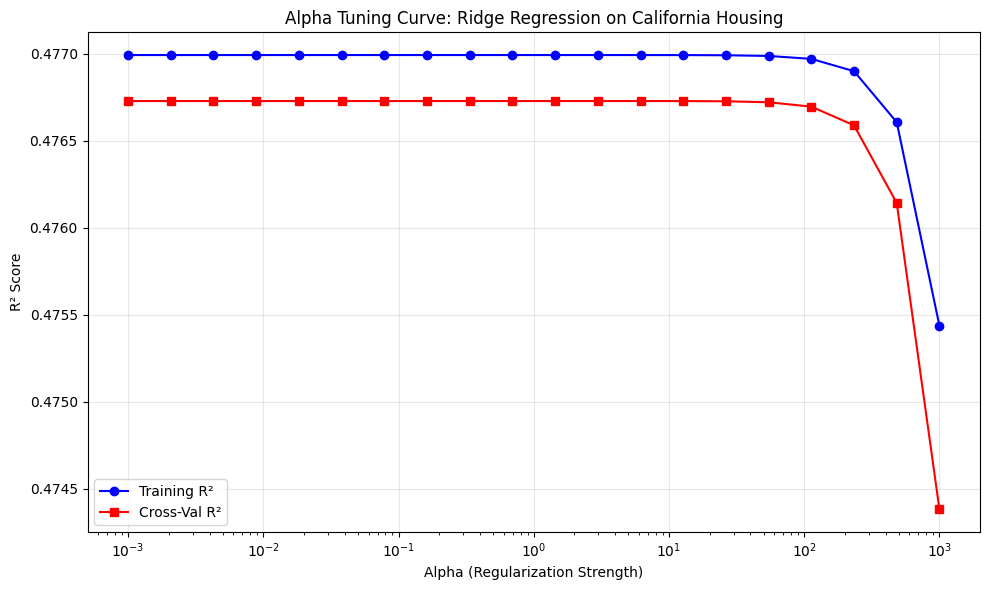

In [2]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Test a range of alpha values
alphas = np.logspace(-3, 3, 20)  # 20 values from 0.001 to 1000

train_scores = []
cv_scores = []

for alpha in alphas:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    
    # Cross-validation score
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())
    
    # Training score
    pipeline.fit(X_train, y_train)
    train_scores.append(pipeline.score(X_train, y_train))

# Plot
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, train_scores, 'b-o', label='Training R²', markersize=6)
plt.semilogx(alphas, cv_scores, 'r-s', label='Cross-Val R²', markersize=6)
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Alpha Tuning Curve: Ridge Regression on California Housing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to notice in this curve

1. **The training curve (blue)** starts high and decreases steadily as alpha increases. More regularization = less ability to fit the training data exactly.

2. **The validation curve (red)** rises at first (less overfitting), peaks, then falls (too much regularization).

3. **The gap** between the two curves at low alpha values shows overfitting. At high alpha values, they converge but at a lower score (underfitting).

4. **The peak** of the validation curve is where you want to be — that's your optimal alpha.

---

## Part 2: Learning Curves

### What it shows

A learning curve plots both the training score and validation score against the **number of training samples**.

**Why we use it:** It answers the question: "Would more data help my model?"

### How to read it

- **Large gap between curves:** The model is overfitting (high variance). Adding more data might help because the model isn't seeing enough examples to learn the pattern.
- **Both curves converge at a low value:** The model is underfitting (high bias). The bottleneck is model complexity, not data quantity. More data won't help.
- **Validation curve still rising:** The model hasn't plateaued. More data would likely improve performance.

### Key insight

Learning curves separate the problem into three buckets: (1) need more data, (2) need simpler model, (3) need more complex model.

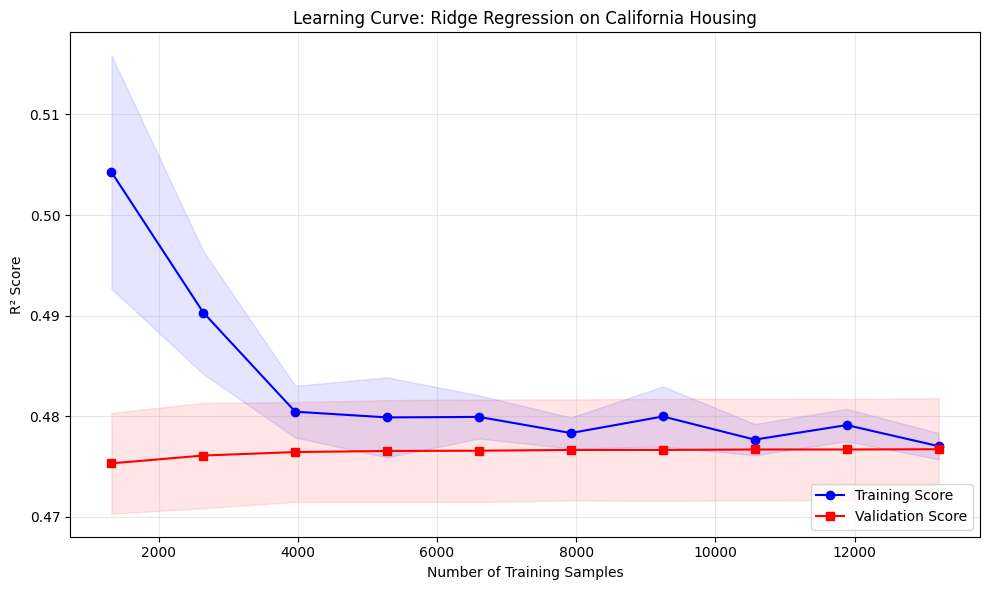

In [3]:
from sklearn.model_selection import learning_curve

# Use Ridge with a moderately tuned alpha
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# Generate learning curve
train_sizes, train_lc_scores, test_lc_scores = learning_curve(
    pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

train_mean = train_lc_scores.mean(axis=1)
train_std = train_lc_scores.std(axis=1)
test_mean = test_lc_scores.mean(axis=1)
test_std = test_lc_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'b-o', label='Training Score', markersize=6)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'r-s', label='Validation Score', markersize=6)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.xlabel('Number of Training Samples')
plt.ylabel('R² Score')
plt.title('Learning Curve: Ridge Regression on California Housing')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to notice in this curve

1. **Both curves are relatively close** — there's no massive gap, which suggests the model isn't severely overfitting.

2. **Both curves are still rising slightly** toward the right edge. The validation score hasn't plateaued, meaning more data might help.

3. **The shaded bands** show the variability across different cross-validation folds. Wider bands mean more variance in the model's performance.

4. **The absolute values** are moderate because we're using just one feature (median income) to predict housing prices. A simple model with limited features has a ceiling on performance.

---

## Summary: When to Use Which

### Alpha Tuning Curve
- **Question:** What is the best regularization strength?
- **X-axis:** Alpha (penalty strength)
- **Use when:** You want to find the optimal hyperparameter and understand the bias-variance tradeoff

### Learning Curve
- **Question:** Would more data help?
- **X-axis:** Number of training samples
- **Use when:** You want to diagnose whether you need more data, a simpler model, or a more complex model

### How they work together

In practice, you often use both:
1. First, tune your alpha (or other hyperparameters) to find the best model architecture
2. Then, check the learning curve to see if gathering more data would be worthwhile

Both are essential tools in your model debugging toolkit.

---

## Quick Reference

| Curve | X-axis | Shows | Problem if gap is large | Problem if gap is small |
|-------|--------|-------|------------------------|------------------------|
| Alpha Tuning | Alpha value | Best regularization strength | Overfitting | N/A (look for peak instead) |
| Learning Curve | Training set size | Need for more data | Overfitting (high variance) | Underfitting (high bias) |